# ЛР 2.1: Логистическая регрессия

## Теоретическая часть

In [174]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression


X,y = make_classification (n_samples=1000,
                          n_features=2,
                          n_informative=2,
                          n_redundant=0,
                          n_classes=2,
                          class_sep=2, # Параметр class_sep задает расстояние (зазор) между классами.
                          random_state=1)


pd.DataFrame(X).head()

,0,1
0,1.863411,0.087646
1,-1.530997,1.901182
2,-0.017224,-2.591112
3,-2.032039,-1.801162
4,4.620555,0.901124


### Построим график сгенерированных точек и признаков

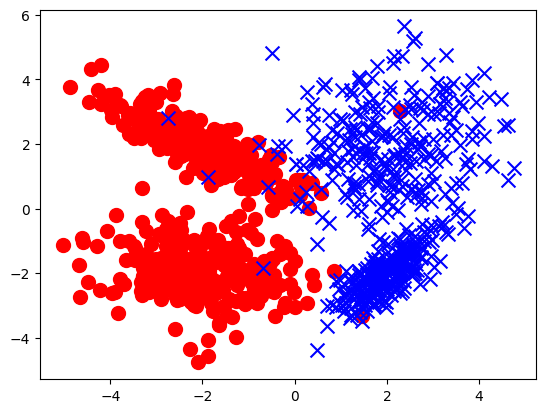

In [175]:
plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)
plt.show()

### Создание класса с базовым функционалом метода градиентного спуска

In [176]:
class SGD():
    def __init__(self, alpha=0.5, n_iters=1000):
        self.b = None
        self._alpha = alpha
        self._n_iters = n_iters

    def gradient_step(self, b, b_grad):
        return b - self._alpha * b_grad

    def optimize(self, X, y, start_b, n_iters):
        b = start_b.copy()
        for i in range(n_iters):
            b_grad = self.grad_func(X, y, b)
            b = self.gradient_step(b, b_grad)
        return b

    def fit(self, X, y):
        m = X.shape[1]
        start_b = np.ones(m)
        self.b = self.optimize(X, y, start_b, self._n_iters)

### Создание класса с логистической регрессии

In [177]:
class LogReg(SGD):
    def sigmoid(self, X, b):
        return 1. / (1. + np.exp(-X.dot(b)))

    def grad_func(self, X, y, b):
        n = X.shape[0]
        grad = 1. / n * X.transpose().dot(self.sigmoid(X, b) - y)
        return grad

    def predict_proba(self, X):
        return self.sigmoid(X, self.b)

    def predict(self, X):
        y_pred = self.predict_proba(X) > 0.5
        return y_pred

### Создание модели

In [178]:
logreg = LogReg()
X = np.hstack([np.ones(X.shape[0])[:, np.newaxis], X]) # Добавим фиктивный столбец единиц к матрице признаков X

logreg.fit(X, y)
y_pred = logreg.predict(X)

### Выведем оосновные метрики качества модели

In [179]:
ac = accuracy_score(y, y_pred)
f1 = f1_score(y, y_pred)
print(f'Accuracy = {ac:.2f} \nF1-score = {f1:.2f}')

Accuracy = 0.98 
F1-score = 0.98


In [180]:
y_pred_proba = logreg.predict_proba(X) # Выведем значения вероятностей для каждого объекта принадлежать тому или иному классу
print(y_pred_proba)

[9.97639678e-01 9.96249026e-03 1.78033798e-01 3.42428157e-04
 9.99999853e-01 9.94911991e-01 9.99992799e-01 4.56440118e-02
 2.53280307e-05 3.21170535e-03 1.19460452e-03 1.19260467e-02
 2.66695847e-04 1.07500577e-02 9.99990715e-01 1.73698870e-02
 2.22330185e-03 6.09293876e-04 5.74500338e-07 3.09750022e-03
 9.98708989e-01 6.21635591e-04 9.30173788e-01 9.99632019e-01
 9.99967273e-01 9.89991235e-01 9.99294711e-01 1.49741182e-02
 9.10740129e-03 8.44634714e-05 1.65740835e-03 2.50277801e-03
 3.42131507e-03 9.92257886e-01 9.94936535e-01 6.02784722e-03
 4.10236778e-04 9.79092004e-01 9.41578080e-01 9.90253866e-01
 9.99442290e-01 7.43864677e-05 2.73557694e-02 9.99995289e-01
 1.91928015e-02 2.56144056e-02 2.91050442e-02 9.82006649e-01
 9.99712939e-01 9.99474718e-01 4.79637535e-01 9.85260816e-01
 2.27946096e-05 9.99913218e-01 9.91390049e-01 9.99572092e-01
 9.89047445e-01 4.73657488e-02 6.96973428e-05 1.18356964e-03
 1.18209574e-05 9.99782625e-01 9.99849962e-01 2.34885345e-04
 9.66067000e-01 2.990425

### Построим график логичстической модели вместе с точками данных

In [181]:
xx, yy = np.meshgrid(
    np.arange(X.min(axis=0)[1]-1, X.max(axis=0)[1]+1, 0.01),
    np.arange(X.min(axis=0)[2]-1, X.max(axis=0)[2]+1, 0.01))
XX = np.array(list(zip(xx.ravel(), yy.ravel()))).reshape((-1, 2))
XX = np.array([(1, *xx) for xx in XX])

In [182]:
Z = logreg.predict_proba(XX)
Z = Z.reshape(xx.shape)

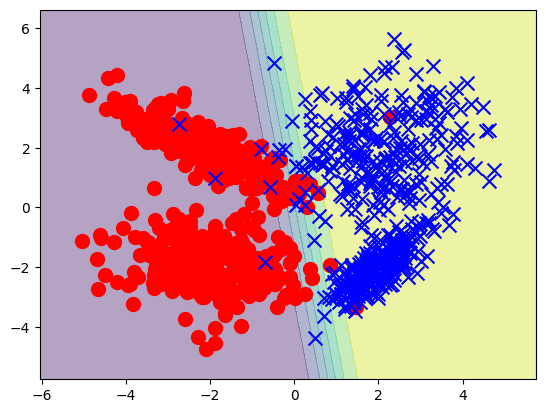

In [183]:
plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X[:, 1][y==0], X[:, 2][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 1][y==1], X[:, 2][y==1], marker="x", c='b', s=100)

### Аналогичное обучение модели, но уже библиотечными функциями

In [184]:
model = LogisticRegression()

model.fit(X, y)
y_pred_lr = model.predict(X)

### Выведем метрики для библиотечной модели

In [185]:
ac = accuracy_score(y, y_pred_lr)
f1 = f1_score(y, y_pred_lr)
print(f'Accuracy = {ac:.2f} \nF1-score = {f1:.2f}')

Accuracy = 0.98 
F1-score = 0.98


# =======================================================================================

# **Самостоятельные задания**

## 1. Вывод результатов работы библиотечной модели - в численном и в графическом виде

Результаты sklearn LogisticRegression:
Accuracy: 0.98
F1-score: 0.98


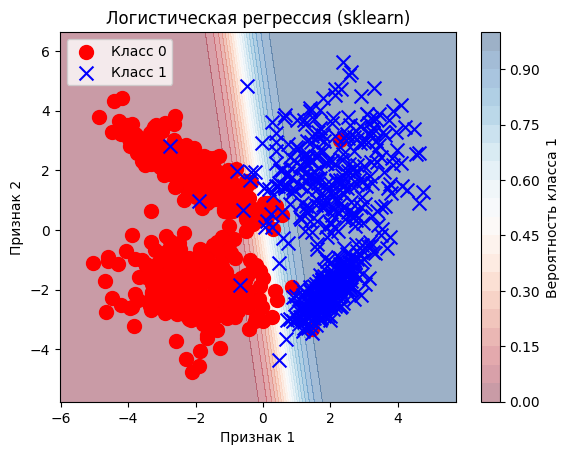

In [186]:
# 1. Генерация данных (повторение, чтобы было полностью автономно)
X, y = make_classification(n_samples=1000,
                           n_features=2,
                           n_informative=2,
                           n_redundant=0,
                           n_classes=2,
                           class_sep=2,
                           random_state=1)

# Добавим фиктивный столбец единиц для моделирования (внутри модели, но для учебных целей можно и так)
# В данном случае sklearn сама это сделает, так что пропускаем.

# 2. Обучение модели из sklearn
model = LogisticRegression()
model.fit(X, y)

# 3. Предсказания
y_pred = model.predict(X)

# 4. Метрики
accuracy = accuracy_score(y, y_pred)
f1 = f1_score(y, y_pred)

print(f"Результаты sklearn LogisticRegression:")
print(f"Accuracy: {accuracy:.2f}")
print(f"F1-score: {f1:.2f}")

# 5. Визуализация данных и границ
# Создаем сетку для отображения границ решений
xx, yy = np.meshgrid(
    np.arange(X[:,0].min() - 1, X[:,0].max() + 1, 0.01),
    np.arange(X[:,1].min() - 1, X[:,1].max() + 1, 0.01)
)

# Предсказания для каждой точки сетки
grid_points = np.c_[xx.ravel(), yy.ravel()]  # объединяем в массив точек
proba = model.predict_proba(grid_points)[:, 1]  # вероятности класса 1
Z = proba.reshape(xx.shape)

# Построение картинкой
plt.contourf(xx, yy, Z, alpha=0.4, levels=20, cmap='RdBu')
plt.colorbar(label='Вероятность класса 1')

# Накладываем точки из исходных данных
plt.scatter(X[y == 0, 0], X[y == 0, 1], marker='o', c='red', s=100, label='Класс 0')
plt.scatter(X[y == 1, 0], X[y == 1, 1], marker='x', c='blue', s=100, label='Класс 1')

plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title('Логистическая регрессия (sklearn)')
plt.legend()
plt.show()

## 2. Проверка других alpha и поиск той, при которой градиентный спуск расходится

In [187]:
X_bias = np.hstack([np.ones((X.shape[0], 1)), X])

class LogisticRegressionWithCheck:
    def __init__(self, alpha=0.1, max_iter=100):
        self.alpha = alpha
        self.max_iter = max_iter
        self.weights = np.zeros(X_bias.shape[1])

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        for i in range(self.max_iter):
            z = X @ self.weights
            preds = self.sigmoid(z)
            gradient = X.T @ (preds - y) / y.size
            self.weights -= self.alpha * gradient

            # Вывод веса для диагностики
            print(f"Итерация {i+1} (alpha = {alpha}): веса = {np.round(self.weights, 2)}")

            # Проверка на растяжение
            if np.max(np.abs(self.weights)) > 1e8:
                print("\nРасхождение обнаружено!")
                return False
        return True


test_alphas = [1e-1, 1e2, 1e4, 1e6, 1e8, 1e10]

for alpha in test_alphas:
    print(f"\nПробуем alpha = {alpha}:\n")
    model = LogisticRegressionWithCheck(alpha=alpha, max_iter=200)
    stable = model.fit(X_bias, y)

    if stable:
        print(f"\nМодель стабильно обучилась на alpha={alpha}.\n")
        print("=" * 100)
    else:
        print(f"Модель расходится на alpha={alpha}.\n")
        print("=" * 100)


Пробуем alpha = 0.1:

Итерация 1 (alpha = 0.1): веса = [ 0.   0.1 -0. ]
Итерация 2 (alpha = 0.1): веса = [ 0.    0.19 -0.  ]
Итерация 3 (alpha = 0.1): веса = [ 0.    0.26 -0.  ]
Итерация 4 (alpha = 0.1): веса = [ 0.    0.33 -0.  ]
Итерация 5 (alpha = 0.1): веса = [ 0.    0.39 -0.  ]
Итерация 6 (alpha = 0.1): веса = [ 0.    0.45 -0.  ]
Итерация 7 (alpha = 0.1): веса = [ 0.   0.5 -0. ]
Итерация 8 (alpha = 0.1): веса = [ 0.    0.54 -0.  ]
Итерация 9 (alpha = 0.1): веса = [ 0.    0.59 -0.  ]
Итерация 10 (alpha = 0.1): веса = [ 0.    0.63 -0.  ]
Итерация 11 (alpha = 0.1): веса = [0.   0.66 0.  ]
Итерация 12 (alpha = 0.1): веса = [0.  0.7 0. ]
Итерация 13 (alpha = 0.1): веса = [0.   0.73 0.  ]
Итерация 14 (alpha = 0.1): веса = [0.   0.76 0.  ]
Итерация 15 (alpha = 0.1): веса = [0.   0.79 0.01]
Итерация 16 (alpha = 0.1): веса = [0.   0.82 0.01]
Итерация 17 (alpha = 0.1): веса = [0.   0.84 0.01]
Итерация 18 (alpha = 0.1): веса = [-0.    0.87  0.01]
Итерация 19 (alpha = 0.1): веса = [-0.    0.

C:\Users\Bush\AppData\Local\Temp\ipykernel_7484\1368695589.py:10: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


## 3. Модификация класса с добалением фиктивного столбца внутри класса

In [188]:
# Базовый класс SGD (градиентный спуск)
class SGD():
    def __init__(self, alpha=0.5, n_iters=1000):
        self.b = None
        self._alpha = alpha
        self._n_iters = n_iters

    def gradient_step(self, b, b_grad):
        return b - self._alpha * b_grad

    def optimize(self, X, y, start_b, n_iters):
        b = start_b.copy()
        for _ in range(n_iters):
            b_grad = self.grad_func(X, y, b)
            b = self.gradient_step(b, b_grad)
        return b

    def fit(self, X, y):
        m = X.shape[1]
        start_b = np.ones(m)
        self.b = self.optimize(X, y, start_b, self._n_iters)


# Класс логистической регрессии
class LogReg(SGD):
    def fit(self, X, y):
        # Перед обучением добавляем фиктивный столбец внутри метода
        self.X_with_bias = np.hstack([np.ones((X.shape[0], 1)), X])

        # Теперь делаем обучение на "обработанных" данных
        super().fit(self.X_with_bias, y)
        # Сохраняем признаки с добавленным столбцом для предсказаний
        self.X_augmented = self.X_with_bias

    def sigmoid(self, X, b):
        return 1. / (1. + np.exp(-X.dot(b)))

    def grad_func(self, X, y, b):
        n = X.shape[0]
        return 1. / n * X.T.dot(self.sigmoid(X, b) - y)

    def predict_proba(self, X):
        # Используем дополнительно добавленный столбец единиц
        if hasattr(self, 'X_with_bias'):
            X_input = np.hstack([np.ones((X.shape[0], 1)), X])
        else:
            X_input = X
        return self.sigmoid(X_input, self.b)

    def predict(self, X):
        proba = self.predict_proba(X)
        return (proba > 0.5).astype(int)


logreg = LogReg()

logreg.fit(X, y)
y_pred = logreg.predict(X)

ac = accuracy_score(y, y_pred_lr)
f1 = f1_score(y, y_pred_lr)
print(f'Accuracy = {ac:.2f} \nF1-score = {f1:.2f}')

Accuracy = 0.98 
F1-score = 0.98


## 4. Изменение параметра class_sep при генерации модели

Результаты с class_sep = 0.001:
Accuracy: 0.53
F1-score: 0.55

          0         1
0 -0.135589 -1.911354
1  0.468003 -0.097818
2  1.981776 -0.592112
3 -0.033039  0.197838
4  2.621555 -1.097876


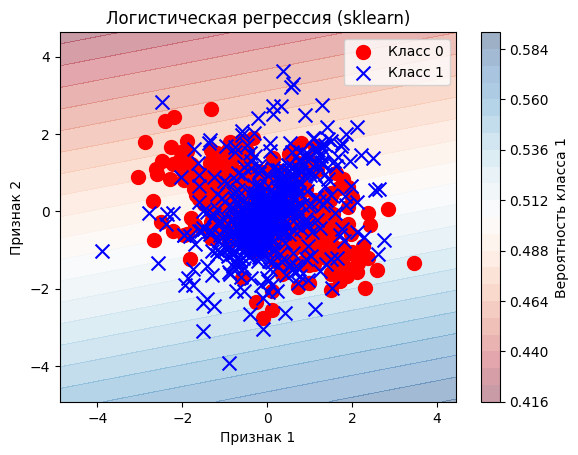


==================================================================================================== >>>

Результаты с class_sep = 0.01:
Accuracy: 0.52
F1-score: 0.53

          0         1
0 -0.126589 -1.902354
1  0.459003 -0.088818
2  1.972776 -0.601112
3 -0.042039  0.188838
4  2.630555 -1.088876


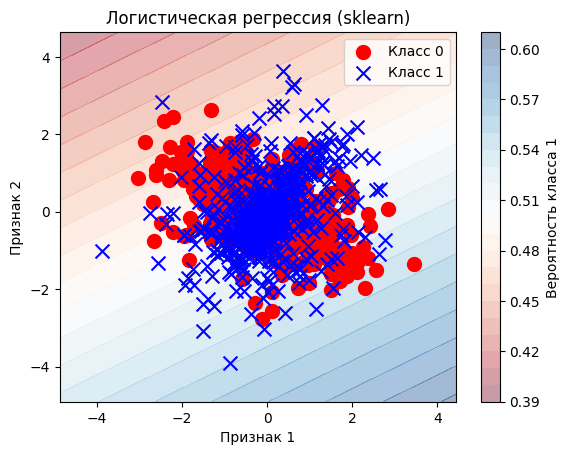


==================================================================================================== >>>

Результаты с class_sep = 0.5:
Accuracy: 0.71
F1-score: 0.71

          0         1
0  0.363411 -1.412354
1 -0.030997  0.401182
2  1.482776 -1.091112
3 -0.532039 -0.301162
4  3.120555 -0.598876


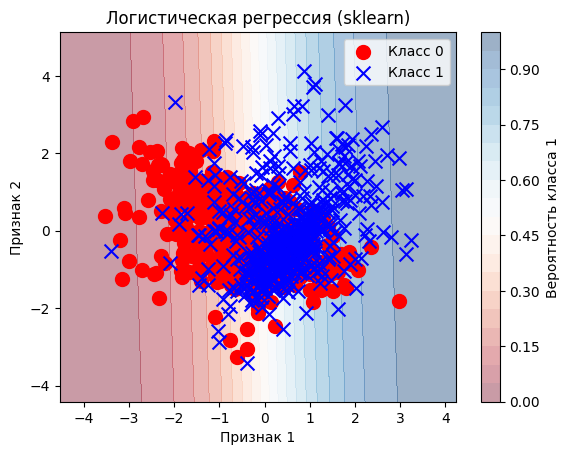


==================================================================================================== >>>

Результаты с class_sep = 1:
Accuracy: 0.85
F1-score: 0.86

          0         1
0  0.863411 -0.912354
1 -0.530997  0.901182
2  0.982776 -1.591112
3 -1.032039 -0.801162
4  3.620555 -0.098876


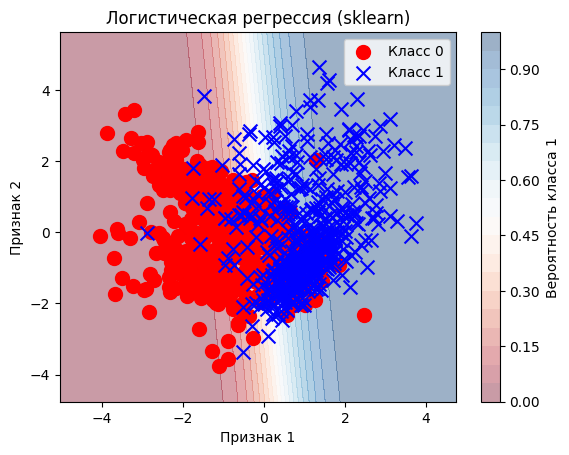


==================================================================================================== >>>

Результаты с class_sep = 2:
Accuracy: 0.98
F1-score: 0.98

          0         1
0  1.863411  0.087646
1 -1.530997  1.901182
2 -0.017224 -2.591112
3 -2.032039 -1.801162
4  4.620555  0.901124


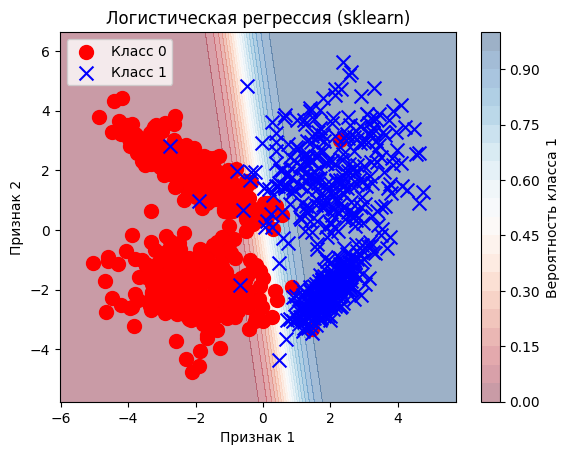


==================================================================================================== >>>

Результаты с class_sep = 2.5:
Accuracy: 0.99
F1-score: 0.99

          0         1
0  2.363411  0.587646
1 -2.030997  2.401182
2 -0.517224 -3.091112
3 -2.532039 -2.301162
4  5.120555  1.401124


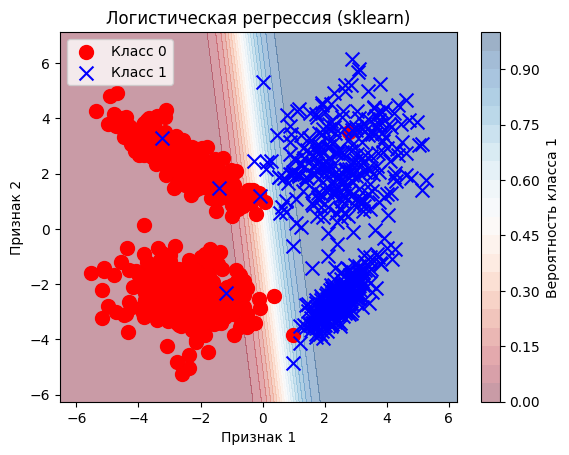


==================================================================================================== >>>

Результаты с class_sep = 4:
Accuracy: 1.00
F1-score: 1.00

          0         1
0  3.863411  2.087646
1 -3.530997  3.901182
2 -2.017224 -4.591112
3 -4.032039 -3.801162
4  6.620555  2.901124


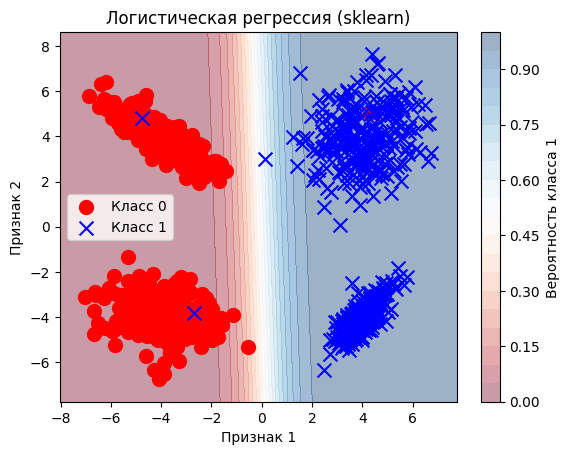


==================================================================================================== >>>



In [189]:
# 0. Задание зазора
class_seps = [0.001, 0.01, 0.5, 1, 2, 2.5, 4]

for i in class_seps:
    # 1. Генерация данных (повторение, чтобы было полностью автономно)
    X, y = make_classification(n_samples=1000,
                               n_features=2,
                               n_informative=2,
                               n_redundant=0,
                               n_classes=2,
                               class_sep=i,
                               random_state=1)

    # Добавим фиктивный столбец единиц для моделирования (внутри модели, но для учебных целей можно и так)
    # В данном случае sklearn сама это сделает, так что пропускаем.

    # 2. Обучение модели из sklearn
    model = LogisticRegression()
    model.fit(X, y)

    # 3. Предсказания
    y_pred = model.predict(X)

    # 4. Метрики
    accuracy = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred)

    print(f"Результаты с class_sep = {i}:")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"F1-score: {f1:.2f}")
    print()
    print(pd.DataFrame(X).head())

    # 5. Визуализация данных и границ
    # Создаем сетку для отображения границ решений
    xx, yy = np.meshgrid(
        np.arange(X[:,0].min() - 1, X[:,0].max() + 1, 0.01),
        np.arange(X[:,1].min() - 1, X[:,1].max() + 1, 0.01)
    )

    # Предсказания для каждой точки сетки
    grid_points = np.c_[xx.ravel(), yy.ravel()]  # объединяем в массив точек
    proba = model.predict_proba(grid_points)[:, 1]  # вероятности класса 1
    Z = proba.reshape(xx.shape)

    # Построение картинкой
    plt.contourf(xx, yy, Z, alpha=0.4, levels=20, cmap='RdBu')
    plt.colorbar(label='Вероятность класса 1')

    # Накладываем точки из исходных данных
    plt.scatter(X[y == 0, 0], X[y == 0, 1], marker='o', c='red', s=100, label='Класс 0')
    plt.scatter(X[y == 1, 0], X[y == 1, 1], marker='x', c='blue', s=100, label='Класс 1')

    plt.xlabel('Признак 1')
    plt.ylabel('Признак 2')
    plt.title('Логистическая регрессия (sklearn)')
    plt.legend()
    plt.show()
    print()
    print("=" * 100, ">>>")
    print()

## 5. Генерация датасета с большим числом признаков

In [190]:
X, y = make_classification(n_samples=1000,
                               n_features=20,
                               n_informative=2,
                               n_redundant=0,
                               n_classes=2,
                               class_sep=2,
                               random_state=1)


logreg = LogReg()

logreg.fit(X, y)
y_pred = logreg.predict(X)

ac = accuracy_score(y, y_pred_lr)
f1 = f1_score(y, y_pred_lr)
print(f'Accuracy = {ac:.2f} \nF1-score = {f1:.2f}')

Accuracy = 0.51 
F1-score = 0.51


In [191]:
pd.DataFrame(X).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,1.274517,0.385414,1.318732,0.003186,-0.498776,1.744953,0.391735,0.619016,0.309818,-0.110357,0.415318,-0.954358,-0.004630,-1.975839,-0.838314,0.604361,1.548457,1.288283,0.757058,-1.066491
1,-1.338032,0.016842,-1.258679,2.227431,1.575400,3.543852,-0.578328,0.840626,-1.524114,-0.494536,-1.244650,-0.423099,0.455077,0.277295,0.266514,1.300153,0.900688,0.503684,0.313562,1.239210
2,0.720662,-0.071649,0.753221,1.785086,-1.882880,-1.829651,0.963882,0.540761,0.433473,0.041179,0.553644,2.641240,1.772515,1.386286,-1.080374,0.072163,-0.017126,-0.899310,-0.977571,2.510869
3,0.618038,0.047401,0.176897,0.579093,-0.851472,2.231779,-0.246996,1.326621,0.304021,0.552453,1.210438,0.499140,1.561449,0.628720,0.144220,0.421754,0.232087,-0.760218,0.218505,-1.481982
4,0.095277,1.589061,1.669372,-1.315472,-1.351164,0.855590,-1.623378,-0.408112,-0.450015,0.475413,0.897684,1.752858,1.055492,-1.027498,-1.990192,1.600626,-0.459313,-0.720490,-0.154038,3.023460


## 6. Множественная классификация (один против всех)

In [192]:
# Генерируем 4 класса для большей сложности
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=4,
    class_sep=2,
    n_clusters_per_class=1,
    random_state=1
)

# Посмотрим на первые 5 строк
print(pd.DataFrame(X).head())

          0         1
0  1.863411  0.087646
1 -1.530997  1.901182
2 -0.017224 -2.591112
3 -2.032039 -1.801162
4  4.620555  0.901124


### Визуализация данных

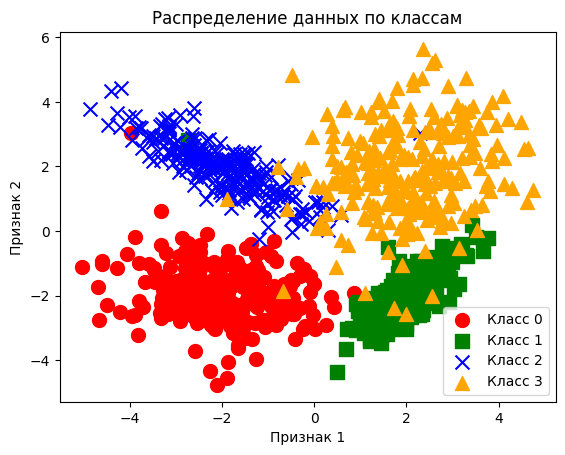

In [193]:
colors = ['r', 'g', 'b', 'orange']
markers = ['o', 's', 'x', '^']

for i in range(4):
    plt.scatter(X[:, 0][y == i], X[:, 1][y == i],
                marker=markers[i], c=colors[i], s=100, label=f'Класс {i}')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.legend()
plt.title('Распределение данных по классам')
plt.show()

### Создание необходимых классов

In [194]:
class OvA:
    def __init__(self):
        self.models = []  # список моделей — по одной для каждого класса

    def fit(self, X, y):
        self.models = []
        self.unique_classes = np.unique(y)
        for cls in self.unique_classes:
            # создаем метки: 1 для текущего класса и 0 для остальных
            y_bin = (y == cls).astype(int)
            # обучаем логистическую регрессию для этого класса
            model = LogisticRegressionBC()
            model.fit(X, y_bin)
            self.models.append(model)

    def predict(self, X):
        # Для каждого класса считаем вероятность принадлежности
        probs = np.array([model.predict_proba(X) for model in self.models])
        # выбираем класс с максимальной вероятностью
        pred_classes = np.argmax(probs, axis=0)
        return self.unique_classes[pred_classes]


class LogisticRegressionBC:
    def __init__(self, alpha=0.1, n_iters=1000):
        self.alpha = alpha
        self.n_iters = n_iters
        self.b = None

    def sigmoid(self, X):
        return 1. / (1. + np.exp(-X.dot(self.b)))

    def fit(self, X, y):
        self.b = np.ones(X.shape[1])
        for _ in range(self.n_iters):
            y_pred = self.sigmoid(X)
            grad = (X.T @ (y_pred - y)) / len(y)
            self.b -= self.alpha * grad

    def predict_proba(self, X):
        return self.sigmoid(X)

    def predict(self, X):
        return (self.sigmoid(X) > 0.5).astype(int)

### Обучаем и смотрим метрики

In [195]:
# Обратим внимание: добавим столбец единиц (свх bias)
X_with_bias = np.hstack([np.ones((X.shape[0], 1)), X])

# Создаем модель "Один против всех"
ova_clf = OvA()
ova_clf.fit(X_with_bias, y)

# Предсказание
y_pred = ova_clf.predict(X_with_bias)

# Метрики качества
from sklearn.metrics import accuracy_score, f1_score

print("Accuracy:", accuracy_score(y, y_pred))
print("F1-score:", f1_score(y, y_pred, average='macro'))

Accuracy: 0.963
F1-score: 0.9630872734205713


### Цветовая наглядная визуализация

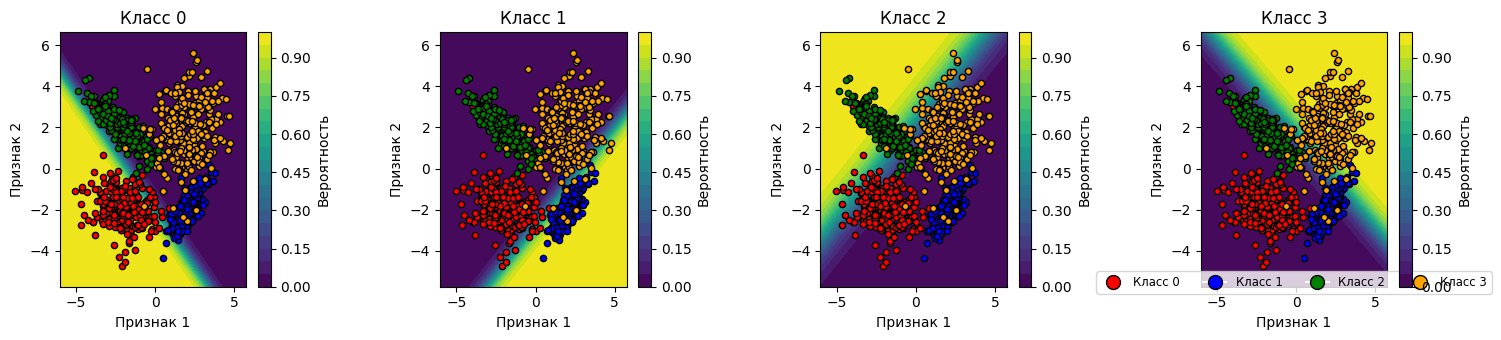

In [196]:
models = []
for class_label in range(4):
    y_binary = (y == class_label).astype(int)
    model = LogisticRegression()
    model.fit(X, y_binary)
    models.append(model)

# Создаем сетку
x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Предсказываем вероятности
probs = []
for model in models:
    prob = model.predict_proba(grid_points)[:, 1]
    probs.append(prob)
probs = np.array(probs)

# Цвета и метки для точек
point_colors = ['red', 'blue', 'green', 'orange']
class_labels = ['Класс 0', 'Класс 1', 'Класс 2', 'Класс 3']

plt.figure(figsize=(15, 3.5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    prob_reshaped = probs[i].reshape(xx.shape)
    contour = plt.contourf(xx, yy, prob_reshaped, levels=20, cmap='viridis')
    # Точки
    for cls_idx, color in enumerate(point_colors):
        plt.scatter(
            X[y == cls_idx, 0], X[y == cls_idx, 1],
            c=color, label=class_labels[cls_idx], edgecolor='k', s=20
        )
    plt.title(f'{class_labels[i]}')
    plt.xlabel('Признак 1')
    plt.ylabel('Признак 2')
    plt.colorbar(contour, label='Вероятность')  # добавляем шкалу вероятностей

# Общая легенда для точек (под графиками)
handles = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                      markerfacecolor=color, markersize=10, markeredgecolor='k')
           for label, color in zip(class_labels, point_colors)]
plt.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=4, fontsize='small')

plt.tight_layout()
plt.show()

## 7. Значение вероятностей каждого объекта классу

     Признак 1  Признак 2  Вероятность класса 0  Вероятность класса 1
0     1.863411   0.087646          3.761502e-03              0.996238
1    -1.530997   1.901182          9.861330e-01              0.013867
2    -0.017224  -2.591112          7.932069e-01              0.206793
3    -2.032039  -1.801162          9.993259e-01              0.000674
4     4.620555   0.901124          5.109292e-07              0.999999
..         ...        ...                   ...                   ...
995   3.143260   3.223026          2.010333e-05              0.999980
996   2.425043  -1.236500          1.113432e-03              0.998887
997   2.330195   4.721810          1.389118e-04              0.999861
998  -2.010841   1.426339          9.973946e-01              0.002605
999  -2.008732   2.245402          9.963674e-01              0.003633

[1000 rows x 4 columns]


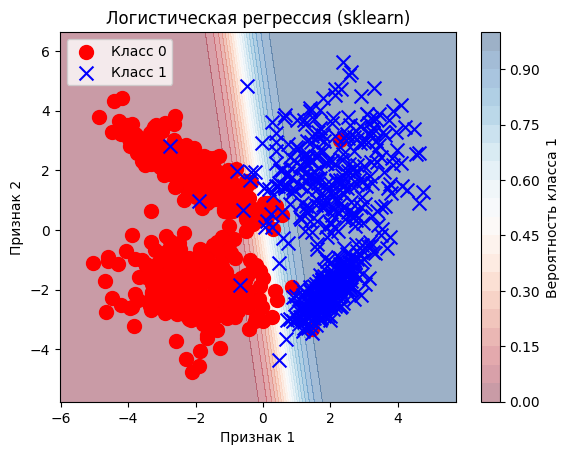

In [197]:
X,y = make_classification (n_samples=1000,
                          n_features=2,
                          n_informative=2,
                          n_redundant=0,
                          n_classes=2,
                          class_sep=2, # Параметр class_sep задает расстояние (зазор) между классами.
                          random_state=1)

model = LogisticRegression()
model.fit(X, y)

# Получаем вероятности для всех объектов
probabilities = model.predict_proba(X)

# Создаем DataFrame с признаками
df = pd.DataFrame(X, columns=["Признак 1", "Признак 2"])

# Добавляем вероятности
df["Вероятность класса 0"] = probabilities[:, 0]
df["Вероятность класса 1"] = probabilities[:, 1]

# Выводим первые 5 строк таблицы
print(df)

# 5. Визуализация данных и границ
# Создаем сетку для отображения границ решений
xx, yy = np.meshgrid(
    np.arange(X[:,0].min() - 1, X[:,0].max() + 1, 0.01),
    np.arange(X[:,1].min() - 1, X[:,1].max() + 1, 0.01)
)

# Предсказания для каждой точки сетки
grid_points = np.c_[xx.ravel(), yy.ravel()]  # объединяем в массив точек
proba = model.predict_proba(grid_points)[:, 1]  # вероятности класса 1
Z = proba.reshape(xx.shape)

# Построение картинкой
plt.contourf(xx, yy, Z, alpha=0.4, levels=20, cmap='RdBu')
plt.colorbar(label='Вероятность класса 1')

# Накладываем точки из исходных данных
plt.scatter(X[y == 0, 0], X[y == 0, 1], marker='o', c='red', s=100, label='Класс 0')
plt.scatter(X[y == 1, 0], X[y == 1, 1], marker='x', c='blue', s=100, label='Класс 1')

plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title('Логистическая регрессия (sklearn)')
plt.legend()
plt.show()